In [22]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix

Імпорт данних

In [3]:
df = pd.read_csv('credit+approval/crx.data', header=None, na_values='?')
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


In [4]:
print(df.isna().sum())

0     12
1     12
2      0
3      6
4      6
5      9
6      9
7      0
8      0
9      0
10     0
11     0
12     0
13    13
14     0
15     0
dtype: int64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       678 non-null    object 
 1   1       678 non-null    float64
 2   2       690 non-null    float64
 3   3       684 non-null    object 
 4   4       684 non-null    object 
 5   5       681 non-null    object 
 6   6       681 non-null    object 
 7   7       690 non-null    float64
 8   8       690 non-null    object 
 9   9       690 non-null    object 
 10  10      690 non-null    int64  
 11  11      690 non-null    object 
 12  12      690 non-null    object 
 13  13      677 non-null    float64
 14  14      690 non-null    int64  
 15  15      690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB


Відсутні дані у не дуже великій кількості клітоник, також деякі данні по парно рівні, тому данні в декількох клітинках можуть бути відсутні на одній строчці. Також данні, як я розумію, зашифровані, тому не зможу підставити якесь базове значення, тому зроблю просто dropna

In [6]:
df = df.dropna()
print(df.isna().sum())

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
dtype: int64


Остання колонка це згодили або відхилили кредит, тому поставлю + як 1, а - як 0

In [7]:
df[15] = df[15].map({'+': 1, '-': 0})
df[15] = df[15].astype(int)

Тепер розіб'ю данні на тренувальні та тестувальні

In [8]:
df_train, df_test = train_test_split(df, test_size=.3, random_state=42)

Розіб'ю данні на числові та катигоральні

In [9]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

Зробимо аналіз числових колонок

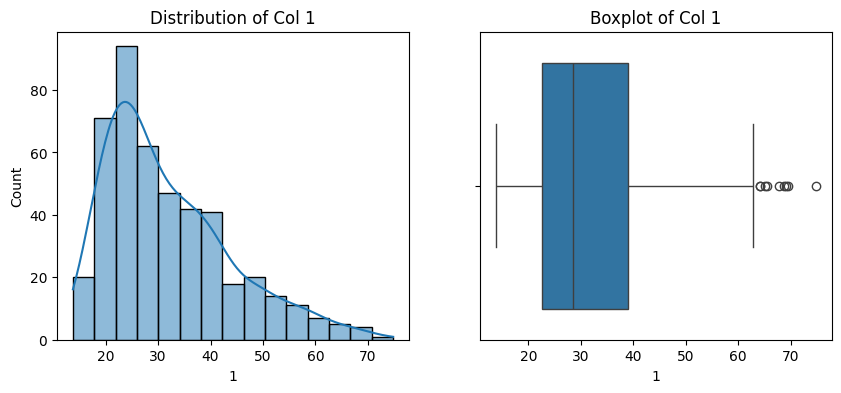

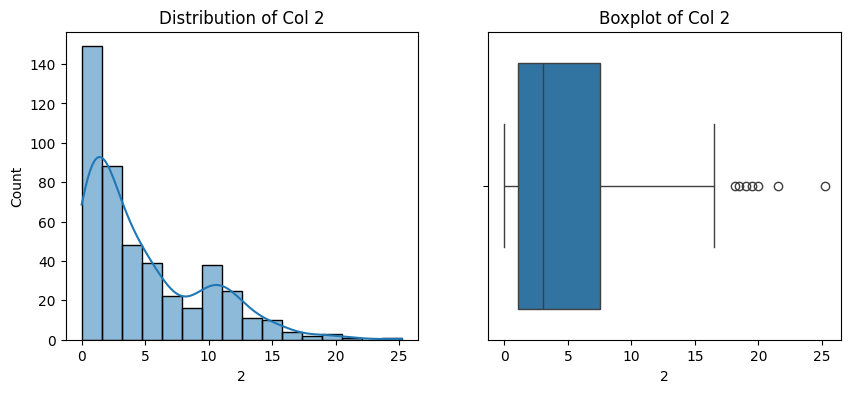

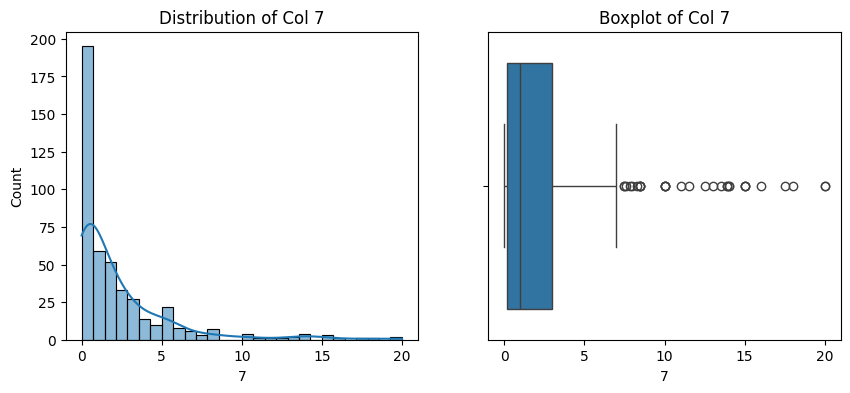

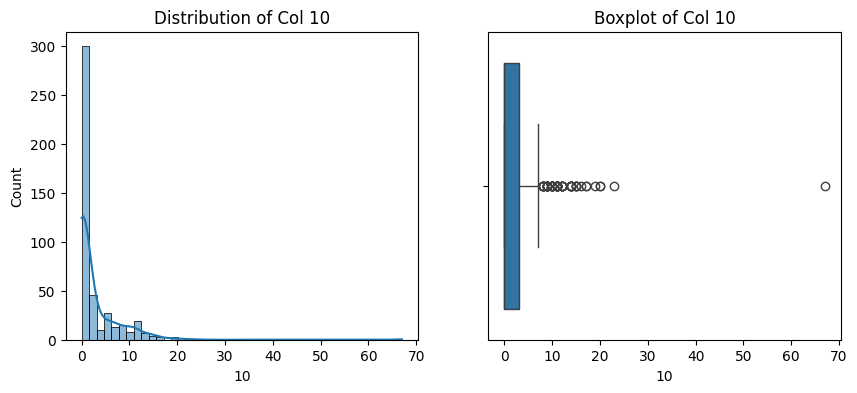

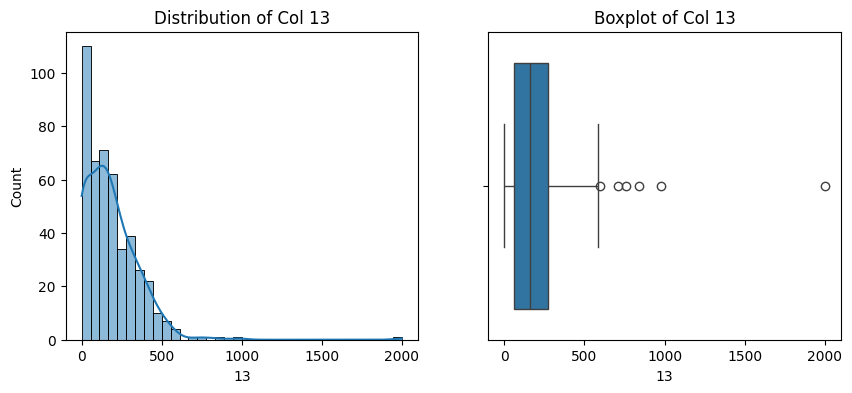

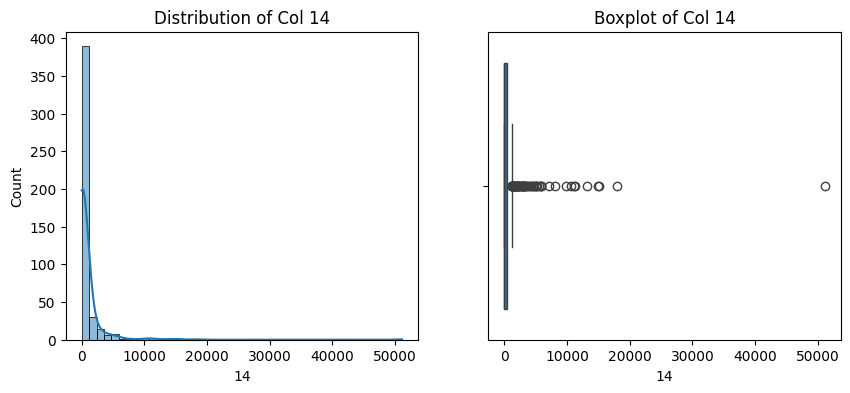

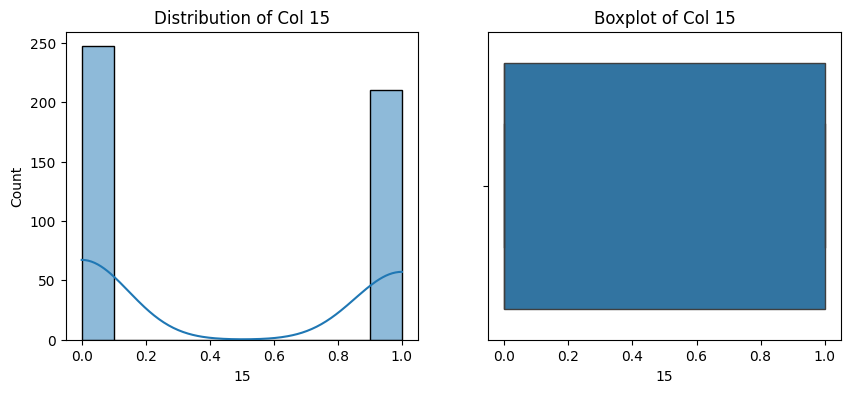

               1           2           7           10           13  \
count  457.000000  457.000000  457.000000  457.000000   457.000000   
mean    31.882954    4.803632    2.255766    2.663020   181.951860   
std     11.965200    4.680203    3.283321    5.202501   176.925032   
min     13.750000    0.000000    0.000000    0.000000     0.000000   
25%     22.670000    1.085000    0.165000    0.000000    60.000000   
50%     28.500000    3.000000    1.000000    0.000000   160.000000   
75%     38.920000    7.500000    3.000000    3.000000   274.000000   
max     74.830000   25.210000   20.000000   67.000000  2000.000000   

                 14          15  
count    457.000000  457.000000  
mean     821.770241    0.459519  
std     3101.488270    0.498905  
min        0.000000    0.000000  
25%        0.000000    0.000000  
50%        6.000000    0.000000  
75%      475.000000    1.000000  
max    51100.000000    1.000000  


In [10]:
for col in num_cols:
    plt.figure(figsize=(10, 4))
    
    # Будуємо гістограми
    plt.subplot(1, 2, 1)
    sns.histplot(df_train[col], kde=True)
    plt.title(f'Distribution of Col {col}')
    
    # Будуємо боксплоти
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_train[col])
    plt.title(f'Boxplot of Col {col}')
    
    plt.show()
    
print(df_train[num_cols].describe())


Усі колонки мають дуже багато вибросів, значень дуже багато на мінімальних значеннях. Нормально виглядає тільки перший графік, ймовірно то вік.

Зроблю Логарифмічну трансформацію для 7, 10, 13, 14 щоб сзгорнути виброси та хвости з графіків

In [11]:
cols_to_log = [7, 10, 13, 14]

df_train[cols_to_log] = np.log1p(df_train[cols_to_log])

Тепер зроблю корреляцію

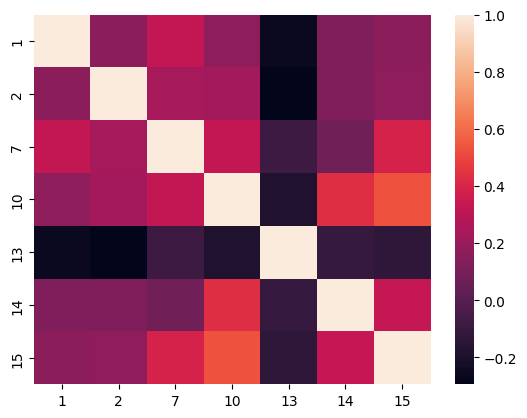

In [12]:
corr_matrix = df_train[num_cols].corr()
sns.heatmap(corr_matrix);

Найкращій зв'язок з 15 колонку має 10 колонка, потім 7 та 14. Колонка 13 має дуже темне значення, тому ми можемо його видалити

In [13]:
df_train = df_train.drop(columns=[13])

Зроблю нормалізацію за допомогою minmaxscaller

In [14]:
num_cols = num_cols.drop([13, 15])
scaler = MinMaxScaler()
X_train = df_train.drop(columns=[15]).copy()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
y_train = df_train[15]

Зроблю всіх дії над дата сетом з test

In [15]:
df_test[cols_to_log] = np.log1p(df_test[cols_to_log])
df_test = df_test.drop(columns=[13])
X_test = df_test.drop(columns=[15]).copy()
X_test[num_cols] = scaler.transform(X_test[num_cols])
y_test = df_test[15]

Перейду до аналізу категоріальних фічей

         0    3    4    5    6    8    9    11   12
count   653  653  653  653  653  653  653  653  653
unique    2    3    3   14    9    2    2    2    3
top       b    u    g    c    v    t    f    f    g
freq    450  499  499  133  381  349  366  351  598


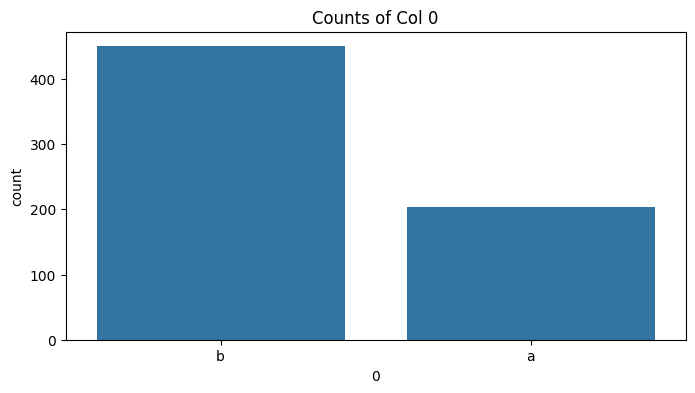

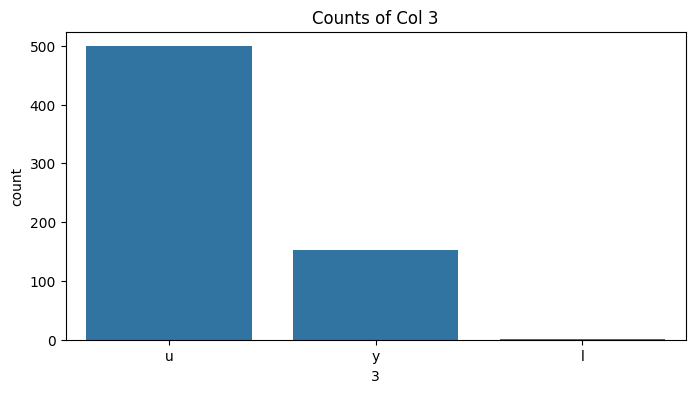

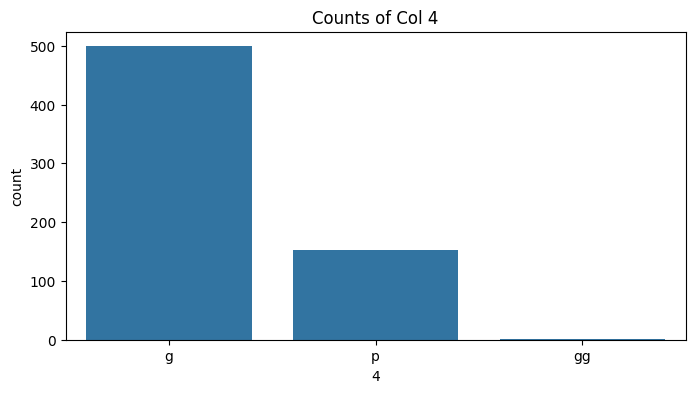

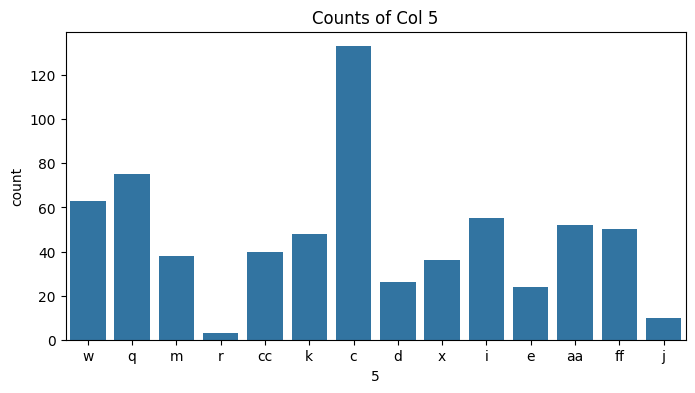

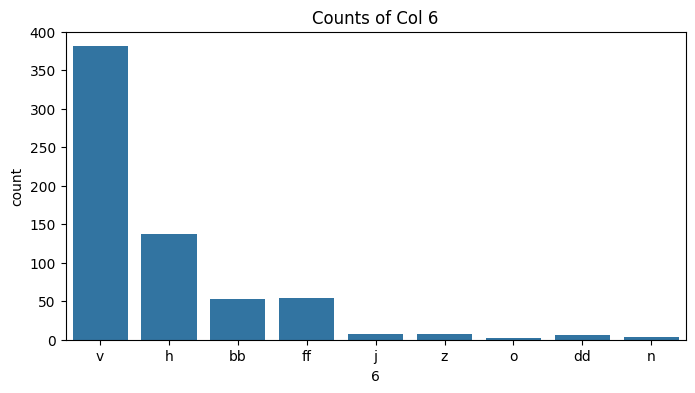

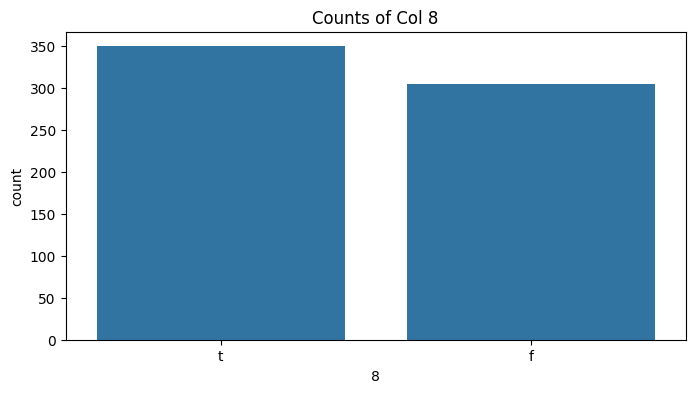

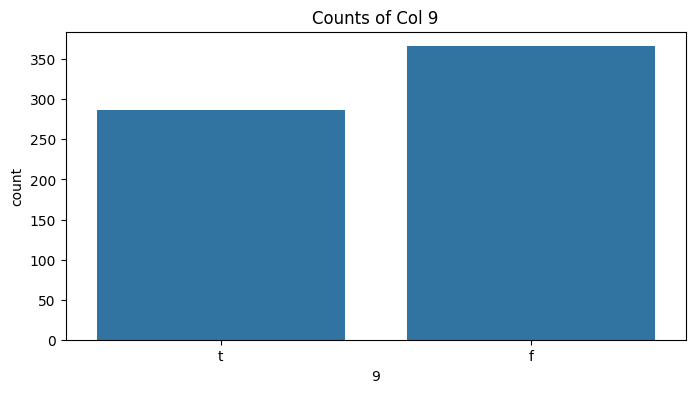

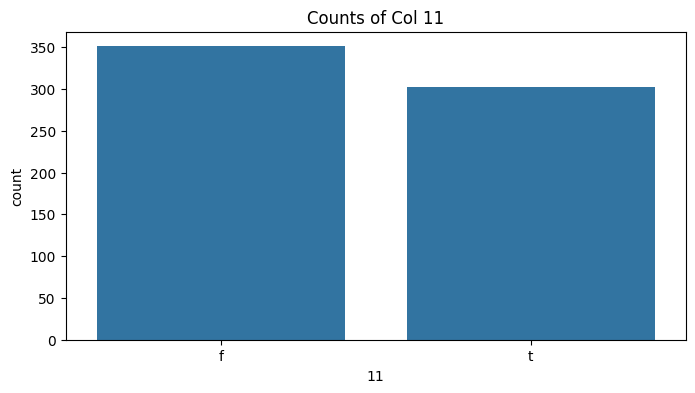

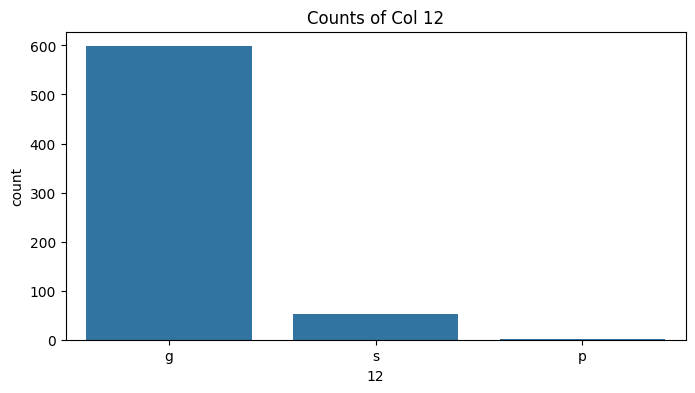

In [16]:
print(df[cat_cols].describe())

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[col])
    plt.title(f'Counts of Col {col}')
    plt.show()

В 12 колонці колонка g занадто домінує, тому її можна видалити

In [17]:
X_train = X_train.drop(columns=[12])
X_test = X_test.drop(columns=[12])
cat_cols = cat_cols.drop(12)

Наступна проблема, що колонки 3, 4, 6 мають рідкі значення, тому використаємо OneHotEncoder

In [18]:
ohe = OneHotEncoder(min_frequency=0.05, handle_unknown='infrequent_if_exist', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', ohe, [0, 3, 4, 5, 6, 8, 9, 11])
    ],
    remainder='passthrough'
)
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

Перевіримо, чи нормально трансформувалося

In [19]:
feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_train_df.head()

,cat__x0_a,cat__x0_b,cat__x3_u,cat__x3_y,cat__x3_infrequent_sklearn,cat__x4_g,cat__x4_p,cat__x4_infrequent_sklearn,cat__x5_aa,cat__x5_c,...,cat__x8_t,cat__x9_f,cat__x9_t,cat__x11_f,cat__x11_t,remainder__x1,remainder__x2,remainder__x7,remainder__x10,remainder__x12
0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.106418,0.395081,0.000000,0.00000,0.000000
1,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,0.478880,0.011503,0.332269,0.52073,0.546931
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.257859,0.043038,0.227670,0.00000,0.243420
3,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,1.0,0.0,0.461198,0.016660,0.062611,0.46117,0.632327
4,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.186968,0.114042,0.206472,0.00000,0.000000


Все добре, можемо пробувати тренувати модель

In [20]:
clf = DecisionTreeClassifier(random_state=42, max_depth=6).fit(X_train, y_train)

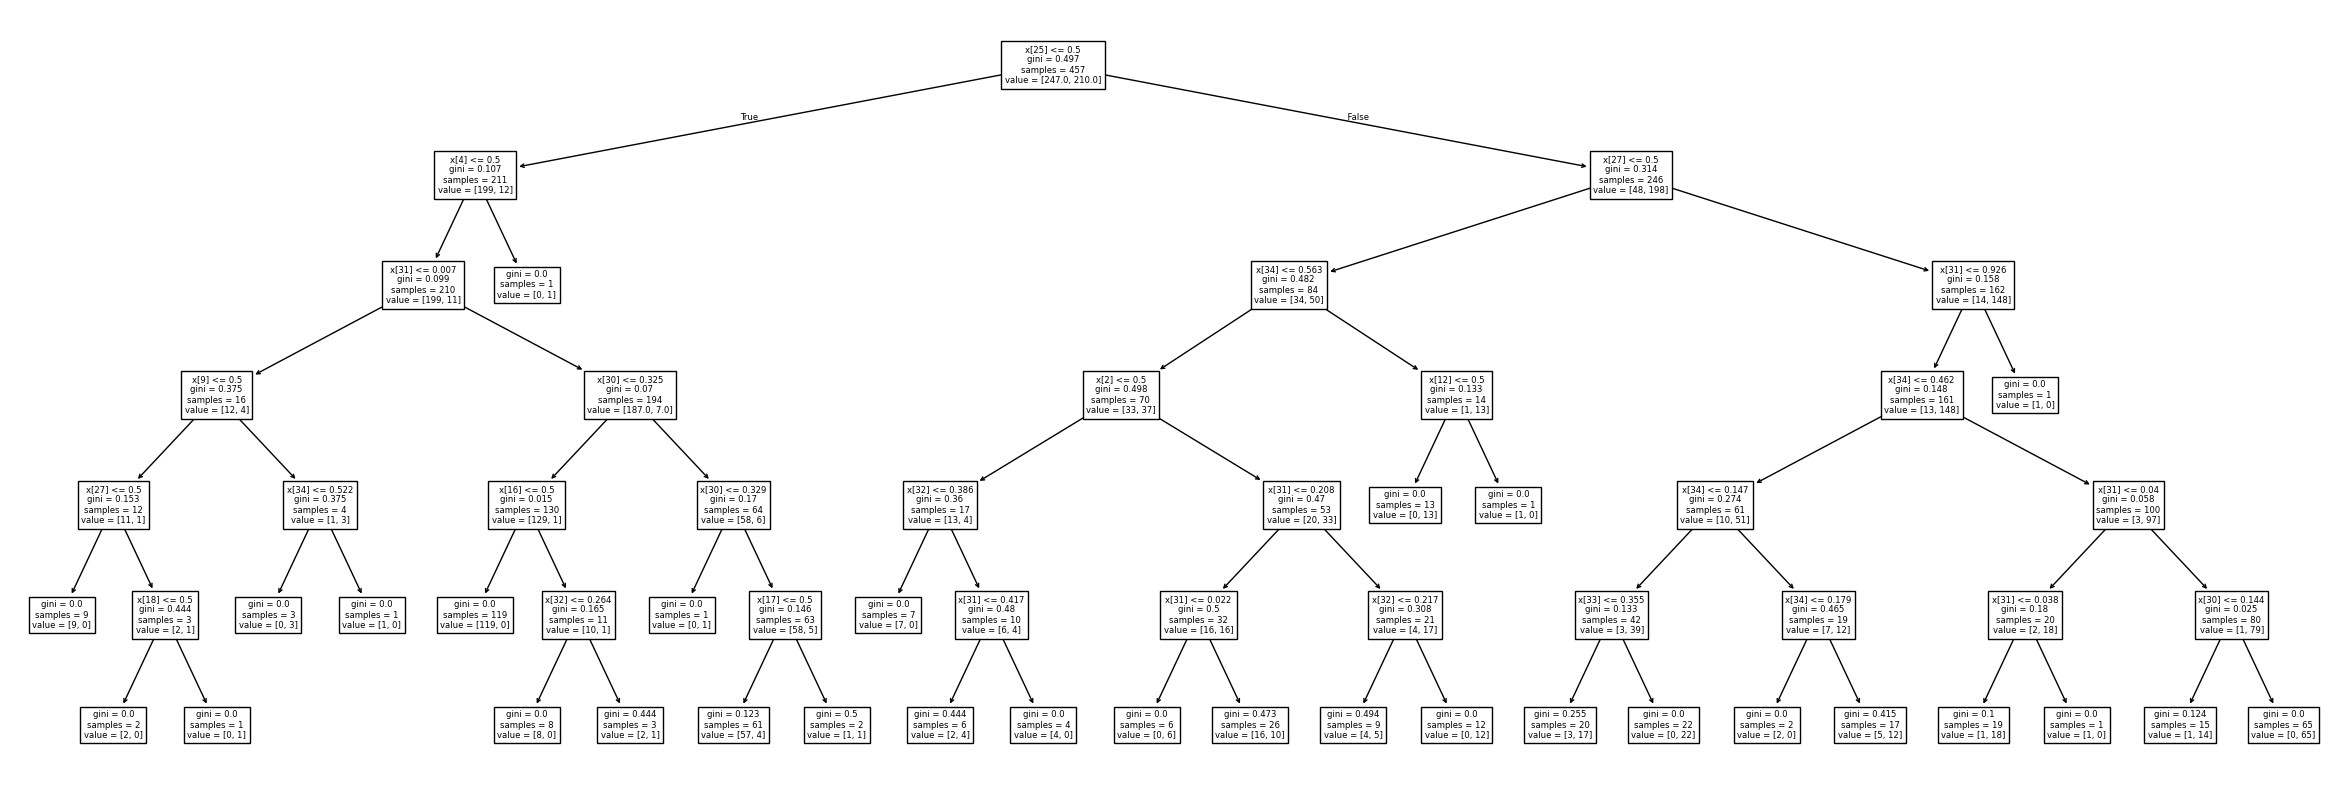

In [29]:
plt.figure(figsize=(30, 10))  # Попробуйте 20x10 или даже больше для больших деревьев
plot_tree(clf)
plt.show()

Тестування:

In [31]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['-','+']))

              precision    recall  f1-score   support

           -       0.81      0.85      0.83       110
           +       0.80      0.74      0.77        86

    accuracy                           0.81       196
   macro avg       0.81      0.80      0.80       196
weighted avg       0.81      0.81      0.81       196

